✓ Libraries imported!
✓ Dataset loaded: 12 rows, 2 columns

EXPLORATORY DATA ANALYSIS

1. First 5 rows:


,age,Age in years
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...



2. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   age           12 non-null     object
 1   Age in years  12 non-null     object
dtypes: object(2)
memory usage: 324.0+ bytes

3. Missing Values:
   No missing values!

4. Duplicates: 0

5. Column Types:
   Categorical: ['age', 'Age in years']
   Numerical: []

6. Target Variable: 'Age in years'
Age in years
Gender ; Male - 1, Female -0                                                                                                                                                                                                                                                         1
Chest pain type                                                                                                                                                                                             

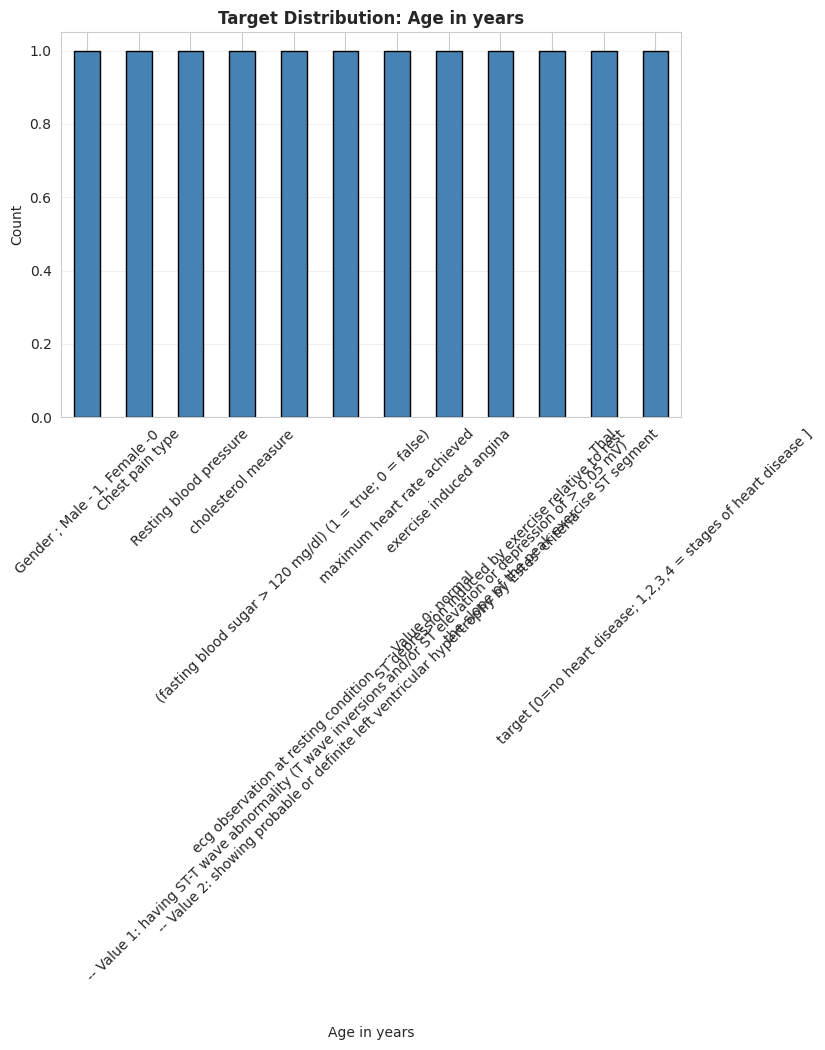


FEATURE ENGINEERING
✓ Encoded 'age'
✓ Encoded target 'Age in years'

DATA SPLITTING

Features: (12, 1)
Target: (12,)
Target classes: [ 2  1  3  6  0  7  9  8  4 11  5 10]

Train: 9 samples
Test: 3 samples

Train target distribution:
Age in years
4     1
7     1
3     1
1     1
10    1
0     1
8     1
6     1
9     1
Name: count, dtype: int64

Test target distribution:
Age in years
5     1
11    1
2     1
Name: count, dtype: int64

BASE MODEL

Training Accuracy: 1.0000
Testing Accuracy: 0.0000

HYPERPARAMETER TUNING (Manual Testing)

Testing configurations...
  Config 1: 0.0000 - {'max_depth': 2, 'criterion': 'gini'}
  Config 2: 0.0000 - {'max_depth': 3, 'criterion': 'gini'}
  Config 3: 0.0000 - {'max_depth': 4, 'criterion': 'gini'}
  Config 4: 0.0000 - {'max_depth': 5, 'criterion': 'gini'}
  Config 5: 0.0000 - {'max_depth': 2, 'criterion': 'entropy'}
  Config 6: 0.0000 - {'max_depth': 3, 'criterion': 'entropy'}
  Config 7: 0.0000 - {'max_depth': None, 'criterion': 'gini', 'min_samples

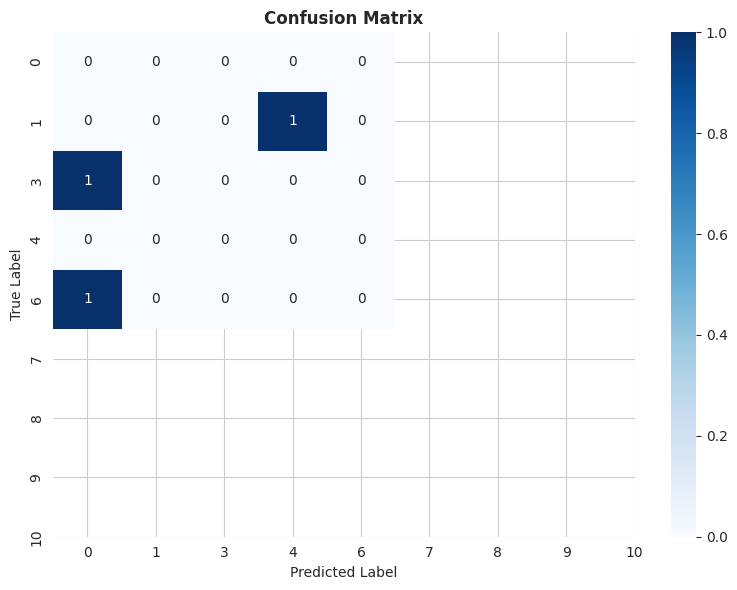


DECISION TREE VISUALIZATION

Tree Depth: 2


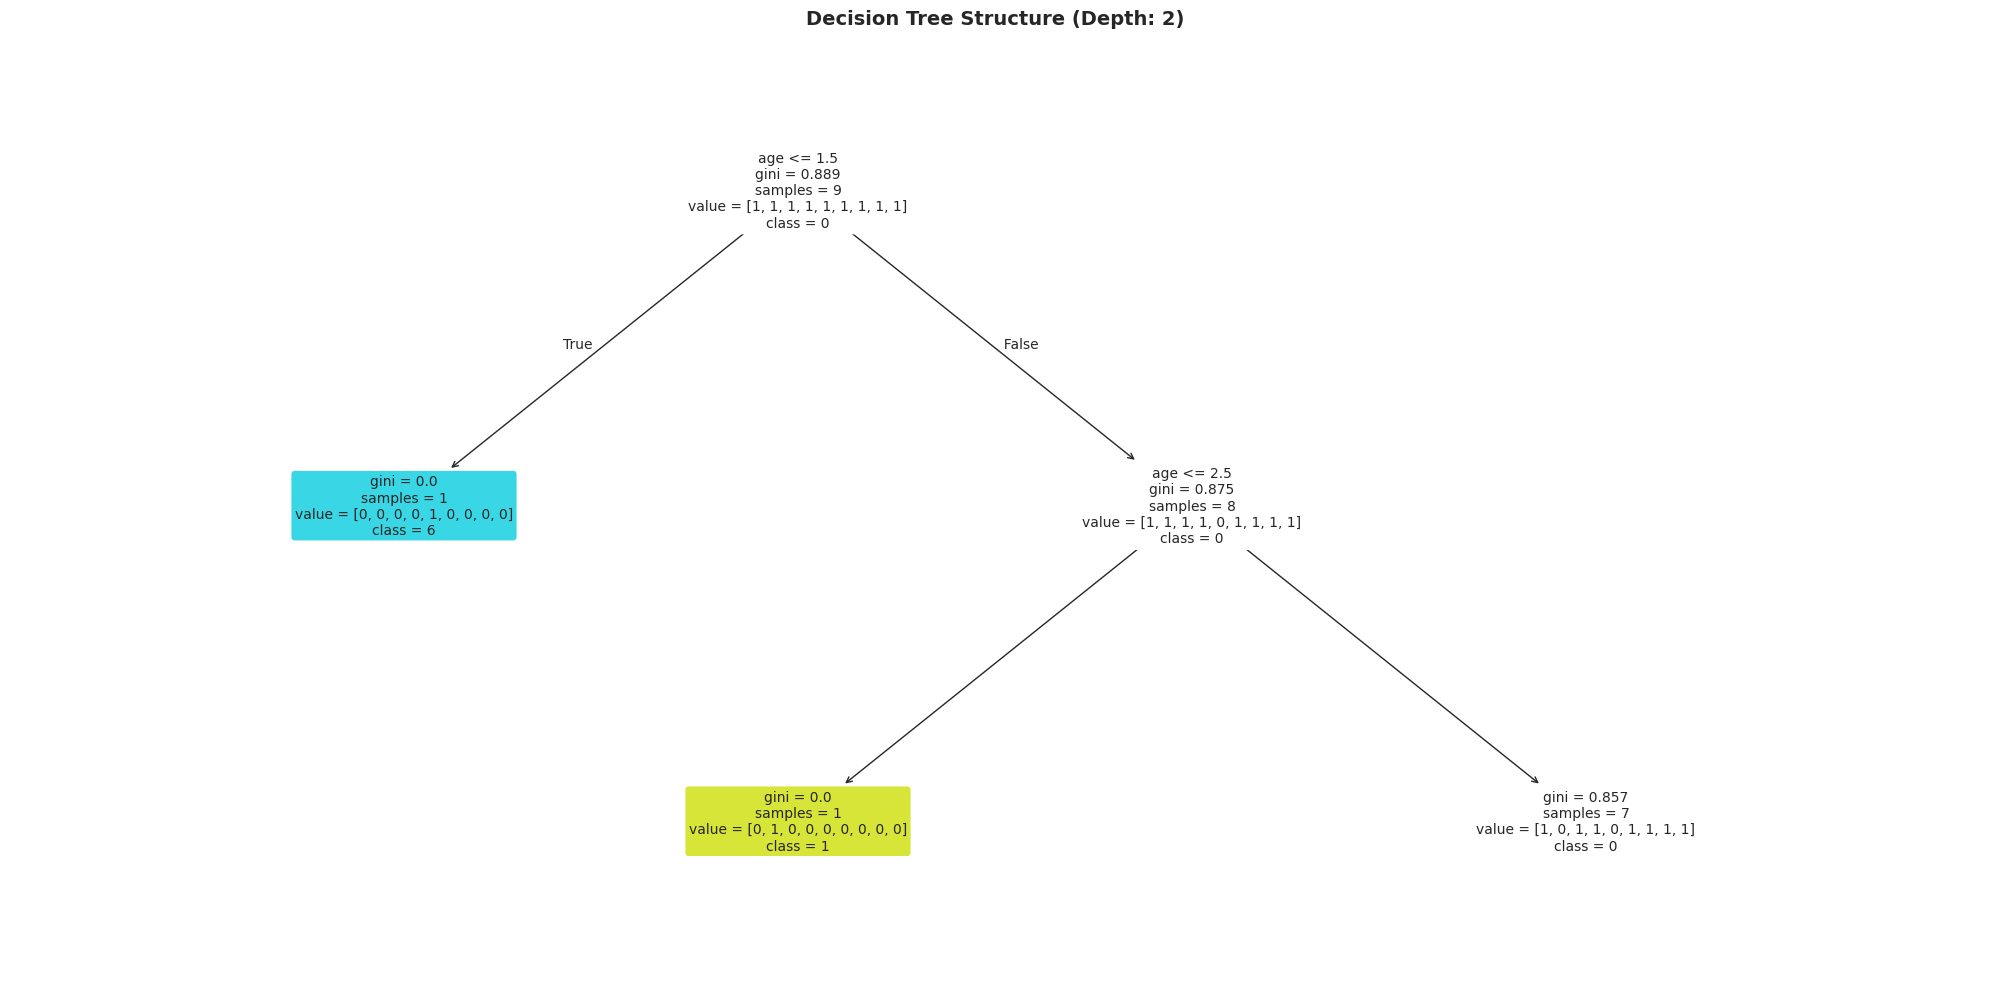


4. FEATURE IMPORTANCE:


,Feature,Importance
0,age,1.0


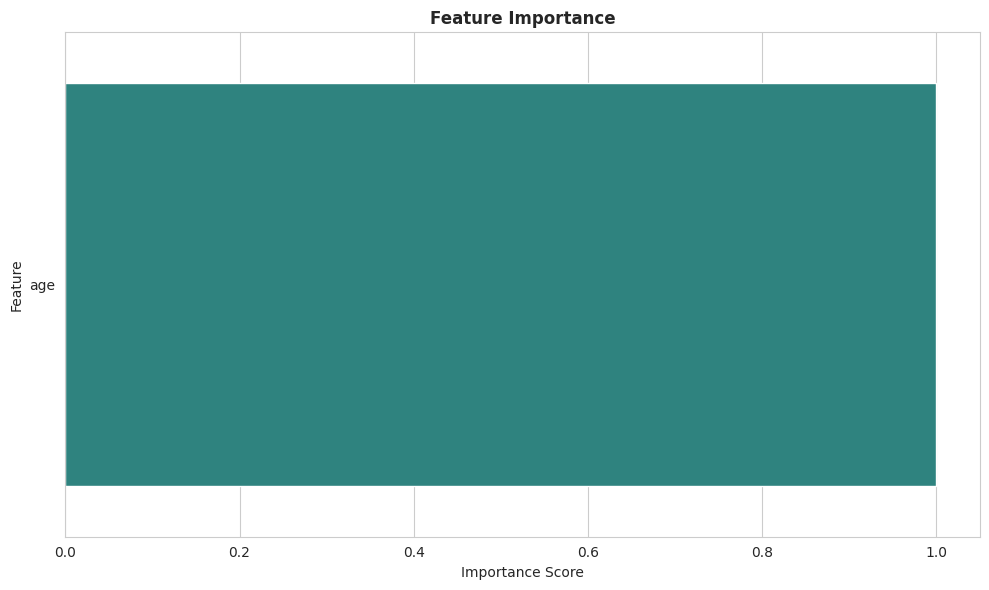


MODEL COMPARISON


,Model,Testing Accuracy,F1-Score
0,Base Model,0.0000,0.0000
1,Optimized Model,0.0000,0.0000


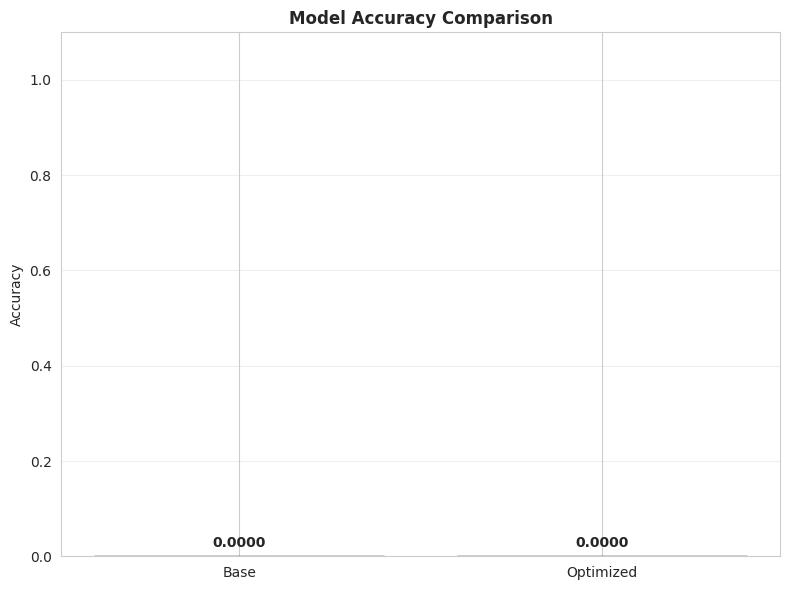


SUMMARY

✓ Dataset: 12 samples, 1 features
✓ Target: 'Age in years' (12 classes)

✓ Final Model:
   Accuracy: 0.0000
   F1-Score: 0.0000
   Best Config: {'max_depth': 2, 'criterion': 'gini'}

⚠️ Note: Small dataset (12 rows)
   Results may not be reliable. Collect more data for better model.

✓ ANALYSIS COMPLETE!


In [5]:
# Decision Tree Classification - Ultra Simple Version
# Guaranteed to work with datasets of ANY size (even 12 rows!)

# ============================================================================
# SETUP
# ============================================================================

!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print("✓ Libraries imported!")

# ============================================================================
# LOAD DATA
# ============================================================================

# Replace with your file_id
file_id = "1vePsODefRCzEXDnO9p7hZzg_TdapTQ4E"

url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_excel(url)

# For CSV: df = pd.read_csv(f"https://drive.google.com/uc?id={file_id}")

print(f"✓ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# ============================================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

print("\n1. First 5 rows:")
display(df.head())

print("\n2. Dataset Info:")
df.info()

print("\n3. Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("   No missing values!")

print(f"\n4. Duplicates: {df.duplicated().sum()}")

# Identify columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n5. Column Types:")
print(f"   Categorical: {categorical_cols}")
print(f"   Numerical: {numerical_cols}")

# ============================================================================
# VISUALIZATIONS
# ============================================================================

# Target variable (last column)
target_column = df.columns[-1]
print(f"\n6. Target Variable: '{target_column}'")
print(df[target_column].value_counts())

# Plot target distribution
plt.figure(figsize=(8, 5))
df[target_column].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title(f'Target Distribution: {target_column}', fontsize=12, fontweight='bold')
plt.xlabel(target_column)
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Histograms
if len(numerical_cols) > 0:
    df[numerical_cols].hist(figsize=(12, 8), bins=10, edgecolor='black', color='lightblue')
    plt.suptitle('Numerical Features Distribution', fontsize=14)
    plt.tight_layout()
    plt.show()

# Correlation
if len(numerical_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm',
                center=0, square=True, fmt='.2f')
    plt.title('Correlation Matrix', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ============================================================================
# FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

df_processed = df.copy()

# Handle missing values
for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        if df_processed[col].dtype in ['int64', 'float64']:
            df_processed[col].fillna(df_processed[col].median(), inplace=True)
        else:
            df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
        print(f"✓ Filled missing values in '{col}'")

# Encode categorical variables
for col in categorical_cols:
    if col != target_column:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        print(f"✓ Encoded '{col}'")

# Encode target
if df_processed[target_column].dtype == 'object':
    le_target = LabelEncoder()
    df_processed[target_column] = le_target.fit_transform(df_processed[target_column])
    print(f"✓ Encoded target '{target_column}'")

# ============================================================================
# TRAIN-TEST SPLIT
# ============================================================================

print("\n" + "="*80)
print("DATA SPLITTING")
print("="*80)

X = df_processed.drop(target_column, axis=1)
y = df_processed[target_column]

print(f"\nFeatures: {X.shape}")
print(f"Target: {y.shape}")
print(f"Target classes: {y.unique()}")

# Simple split (no stratification to avoid errors)
# For very small datasets, adjust test size
if len(X) < 10:
    test_size = 0.3  # Use 30% for test
    print(f"\n⚠️ Very small dataset. Using 70-30 split.")
else:
    test_size = 0.2  # Use 20% for test

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42
)

print(f"\nTrain: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")

# Check if we have enough test samples
if len(X_test) == 0:
    print("\n⚠️ ERROR: Test set is empty! Using different split...")
    # Use a single sample for testing
    X_train = X[:-1]
    X_test = X[-1:]
    y_train = y[:-1]
    y_test = y[-1:]
    print(f"Adjusted - Train: {len(X_train)}, Test: {len(X_test)}")

print(f"\nTrain target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

# ============================================================================
# BASE MODEL
# ============================================================================

print("\n" + "="*80)
print("BASE MODEL")
print("="*80)

dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

y_pred_train = dt_base.predict(X_train)
y_pred_test = dt_base.predict(X_test)

print(f"\nTraining Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_test):.4f}")

# ============================================================================
# MANUAL HYPERPARAMETER TUNING
# ============================================================================

print("\n" + "="*80)
print("HYPERPARAMETER TUNING (Manual Testing)")
print("="*80)

# Test different configurations
configs = [
    {'max_depth': 2, 'criterion': 'gini'},
    {'max_depth': 3, 'criterion': 'gini'},
    {'max_depth': 4, 'criterion': 'gini'},
    {'max_depth': 5, 'criterion': 'gini'},
    {'max_depth': 2, 'criterion': 'entropy'},
    {'max_depth': 3, 'criterion': 'entropy'},
    {'max_depth': None, 'criterion': 'gini', 'min_samples_leaf': 2},
]

results = []
best_score = -1  # Changed from 0 to -1
best_model = dt_base  # Initialize with base model
best_config = {'max_depth': None, 'criterion': 'gini'}  # Default config

print("\nTesting configurations...")
for i, config in enumerate(configs, 1):
    try:
        dt = DecisionTreeClassifier(random_state=42, **config)
        dt.fit(X_train, y_train)
        score = dt.score(X_test, y_test)
        results.append({'Config': i, 'Params': config, 'Score': score})
        print(f"  Config {i}: {score:.4f} - {config}")

        if score > best_score:
            best_score = score
            best_model = dt
            best_config = config
    except Exception as e:
        print(f"  Config {i}: Failed - {config}")

# Ensure we have a valid model
if best_model is None:
    print("\n⚠️ No valid configuration found. Using base model.")
    best_model = dt_base
    best_config = {'default': 'base model'}
    best_score = accuracy_score(y_test, y_pred_test)

print(f"\n✓ Best Configuration: {best_config}")
print(f"✓ Best Score: {best_score:.4f}")

dt_optimized = best_model

# ============================================================================
# MODEL EVALUATION
# ============================================================================

print("\n" + "="*80)
print("FINAL MODEL EVALUATION")
print("="*80)

y_pred_final = dt_optimized.predict(X_test)

print("\n1. ACCURACY:")
print(f"   Testing Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")

print("\n2. METRICS:")
print(f"   Precision: {precision_score(y_test, y_pred_final, average='weighted', zero_division=0):.4f}")
print(f"   Recall: {recall_score(y_test, y_pred_final, average='weighted', zero_division=0):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_final, average='weighted', zero_division=0):.4f}")

print("\n3. CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred_final, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=dt_optimized.classes_, yticklabels=dt_optimized.classes_)
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ============================================================================
# DECISION TREE VISUALIZATION
# ============================================================================

print("\n" + "="*80)
print("DECISION TREE VISUALIZATION")
print("="*80)

tree_depth = dt_optimized.get_depth()
print(f"\nTree Depth: {tree_depth}")

plt.figure(figsize=(20, 10))
plot_tree(dt_optimized,
          feature_names=X.columns,
          class_names=[str(c) for c in dt_optimized.classes_],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title(f'Decision Tree Structure (Depth: {tree_depth})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Feature Importance
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_optimized.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n4. FEATURE IMPORTANCE:")
display(feature_imp)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# ============================================================================
# COMPARISON
# ============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

comparison = pd.DataFrame({
    'Model': ['Base Model', 'Optimized Model'],
    'Testing Accuracy': [
        f"{accuracy_score(y_test, y_pred_test):.4f}",
        f"{accuracy_score(y_test, y_pred_final):.4f}"
    ],
    'F1-Score': [
        f"{f1_score(y_test, y_pred_test, average='weighted', zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_final, average='weighted', zero_division=0):.4f}"
    ]
})

display(comparison)

# Plot comparison
acc_comparison = pd.DataFrame({
    'Model': ['Base', 'Optimized'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_test),
        accuracy_score(y_test, y_pred_final)
    ]
})

plt.figure(figsize=(8, 6))
plt.bar(acc_comparison['Model'], acc_comparison['Accuracy'], color=['steelblue', 'coral'], edgecolor='black')
plt.title('Model Accuracy Comparison', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(acc_comparison['Accuracy']):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print(f"\n✓ Dataset: {len(df)} samples, {X.shape[1]} features")
print(f"✓ Target: '{target_column}' ({len(y.unique())} classes)")
print(f"\n✓ Final Model:")
print(f"   Accuracy: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_final, average='weighted', zero_division=0):.4f}")
print(f"   Best Config: {best_config}")

if len(df) < 30:
    print(f"\n⚠️ Note: Small dataset ({len(df)} rows)")
    print("   Results may not be reliable. Collect more data for better model.")

print("\n" + "="*80)
print("✓ ANALYSIS COMPLETE!")
print("="*80)